# ETS (exponential smoothing)

ETS models describe a series through slowly evolving *states* — level, optional trend, optional seasonality — updated by exponential smoothing. The error/trend/season taxonomy spans 30 variants (additive or multiplicative, damped or not), so a single generator covers a broad family of realistic trend-plus-seasonality shapes.

::: {.callout-note}
## The model

Each series is built from a level state plus optional trend and seasonal states, combined additively or multiplicatively via `error_type`, `trend_type`, `seasonal_type`, and `damped`. This is the state-space form behind Holt and Holt-Winters smoothing.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import ETSGenerator

## Example 1: Damped Additive Holt-Winters ETS(A,Ad,A)

An additive model with weekly seasonality and a damped trend.

In [ ]:
params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "error_type": "add",
    "trend_type": "add",
    "seasonal_type": "add",
    "seasonal_period": 7,
    "level": 100.0,
    "trend": 0.5,
    "alpha": 0.3,
    "beta": 0.1,
    "gamma": 0.1,
    "damped": True,
    "phi": 0.95,
    "noise_std": 2.0,
    "seed": 123,
}

generator = ETSGenerator(engine="polars", **params)

### Model Information

In [ ]:
model_info = generator.get_model_info()
print(f"Model: {model_info['model']}")
print(f"Initial level: {model_info['level']}")
print(f"Initial trend: {model_info['trend']}")
print(f"Smoothing parameters: alpha={model_info['alpha']}, beta={model_info['beta']}, gamma={model_info['gamma']}")
print(f"Damping parameter: phi={model_info['phi']}")

Model: ETS(A,Ad,A)
Initial level: 100.0
Initial trend: 0.5
Smoothing parameters: alpha=0.3, beta=0.1, gamma=0.1
Damping parameter: phi=0.95


### Generate and Inspect Data

In [ ]:
df = generator.generate(n_series=3)
print(f"Generated {df['unique_id'].n_unique()} time series")
print(f"Total observations: {len(df)}")
df.head(10)

Generated 3 time series
Total observations: 600


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.240791
"""0""",2000-01-02 00:00:00,95.591069
"""0""",2000-01-03 00:00:00,97.083479
"""0""",2000-01-04 00:00:00,99.609554
"""0""",2000-01-05 00:00:00,98.526403
"""0""",2000-01-06 00:00:00,103.635379
"""0""",2000-01-07 00:00:00,107.23276
"""0""",2000-01-08 00:00:00,103.376507
"""0""",2000-01-09 00:00:00,94.880221


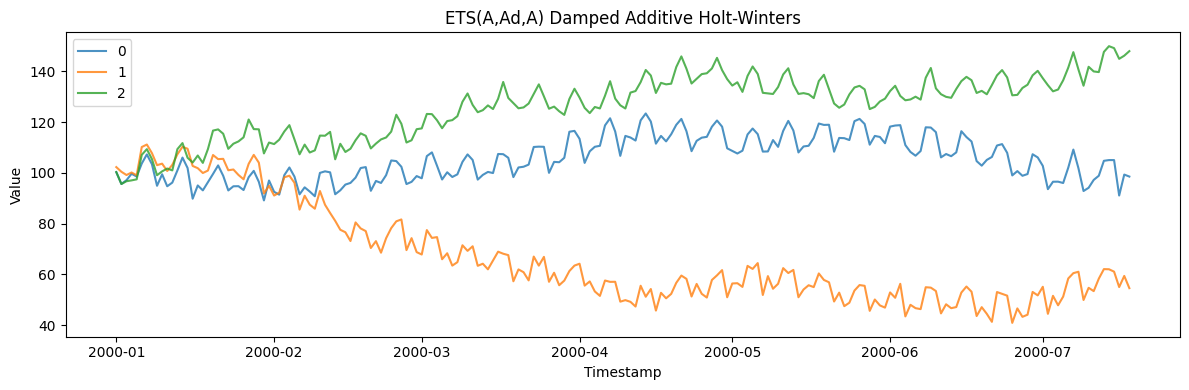

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df["unique_id"].unique().to_list():
    series = df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("ETS(A,Ad,A) Damped Additive Holt-Winters")
ax.legend()
plt.tight_layout()
plt.show()

### Statistics by Series

In [ ]:
df.group_by("unique_id").agg(
    [
        pl.col("y").count().alias("count"),
        pl.col("y").min().alias("min_value"),
        pl.col("y").max().alias("max_value"),
        pl.col("y").mean().alias("mean_value"),
        pl.col("y").std().alias("std_value"),
    ]
).sort("unique_id")

unique_id,count,min_value,max_value,mean_value,std_value
cat,u32,f64,f64,f64,f64
"""0""",200,89.114448,123.364807,105.517095,8.448336
"""1""",200,40.87026,111.131822,66.927617,19.298572
"""2""",200,95.571068,149.87852,126.124841,12.339277


## Example 2: ETS(A,A,A) with State Export

Generate data and extract the underlying level, trend, and seasonal state components.

In [ ]:
params_states = {
    "min_length": 50,
    "max_length": 50,
    "freq": "D",
    "error_type": "add",
    "trend_type": "add",
    "seasonal_type": "add",
    "seasonal_period": 7,
    "level": 100.0,
    "trend": 1.0,
    "alpha": 0.3,
    "beta": 0.1,
    "gamma": 0.1,
    "noise_std": 1.0,
    "seed": 42,
}

generator_states = ETSGenerator(engine="polars", **params_states)
obs_df, states_df = generator_states.generate_with_states(n_series=1)

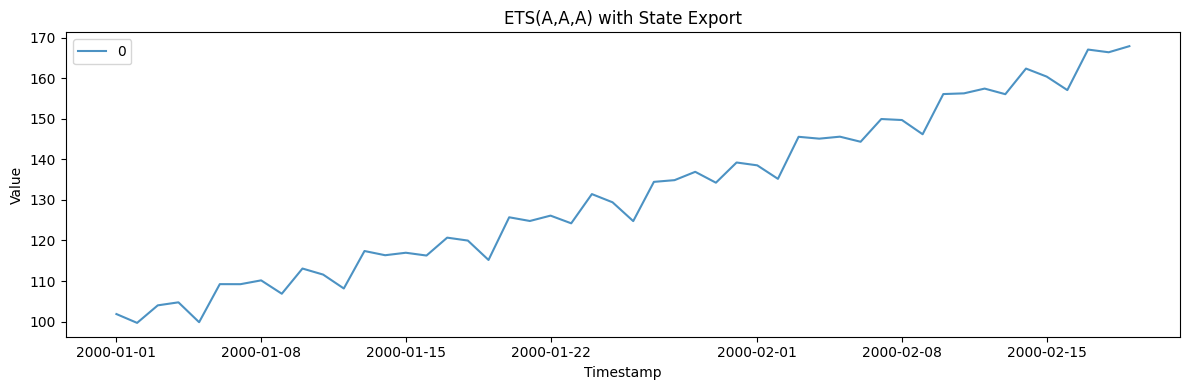

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in obs_df["unique_id"].unique().to_list():
    series = obs_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("ETS(A,A,A) with State Export")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("Observations DataFrame:")
obs_df.head(10)

Observations DataFrame:


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,101.852261
"""0""",2000-01-02 00:00:00,99.674429
"""0""",2000-01-03 00:00:00,103.997037
"""0""",2000-01-04 00:00:00,104.742658
"""0""",2000-01-05 00:00:00,99.842295
"""0""",2000-01-06 00:00:00,109.225432
"""0""",2000-01-07 00:00:00,109.215338
"""0""",2000-01-08 00:00:00,110.156755
"""0""",2000-01-09 00:00:00,106.862563


In [ ]:
print("States DataFrame (level, trend, seasonal components):")
states_df.head(10)

States DataFrame (level, trend, seasonal components):


unique_id,ds,level,trend,seasonal_0,seasonal_1,seasonal_2,seasonal_3,seasonal_4,seasonal_5,seasonal_6
cat,datetime[ns],f64,f64,f64,f64,f64,f64,f64,f64,f64
"""0""",2000-01-01 00:00:00,100.0,1.0,1.168504,-2.182273,2.014922,0.402623,-5.629283,3.185167,1.04034
"""0""",2000-01-02 00:00:00,100.905127,0.968376,1.136879,-2.182273,2.014922,0.402623,-5.629283,3.185167,1.04034
"""0""",2000-01-03 00:00:00,101.868463,0.966696,1.136879,-2.183953,2.014922,0.402623,-5.629283,3.185167,1.04034
"""0""",2000-01-04 00:00:00,102.579245,0.881391,1.136879,-2.183953,1.929618,0.402623,-5.629283,3.185167,1.04034
"""0""",2000-01-05 00:00:00,103.724456,0.969331,1.136879,-2.183953,1.929618,0.490563,-5.629283,3.185167,1.04034
"""0""",2000-01-06 00:00:00,104.927124,1.04711,1.136879,-2.183953,1.929618,0.490563,-5.551504,3.185167,1.04034
"""0""",2000-01-07 00:00:00,105.994044,1.053713,1.136879,-2.183953,1.929618,0.490563,-5.551504,3.19177,1.04034
"""0""",2000-01-08 00:00:00,107.385929,1.166437,1.136879,-2.183953,1.929618,0.490563,-5.551504,3.19177,1.153064
"""0""",2000-01-09 00:00:00,108.69262,1.213188,1.18363,-2.183953,1.929618,0.490563,-5.551504,3.19177,1.153064


## Example 3: Multiplicative Holt-Winters ETS(M,A,M)

A multiplicative error and seasonal model with monthly frequency. All values remain positive.

In [ ]:
params_mul = {
    "min_length": 200,
    "max_length": 200,
    "freq": "MS",
    "error_type": "mul",
    "trend_type": "add",
    "seasonal_type": "mul",
    "seasonal_period": 12,
    "level": 100.0,
    "trend": 1.0,
    "alpha": 0.3,
    "beta": 0.1,
    "gamma": 0.1,
    "noise_std": 0.1,
    "seed": 456,
}

generator_mul = ETSGenerator(engine="polars", **params_mul)
df_mul = generator_mul.generate(n_series=1)

print(f"Model: {generator_mul.get_model_info()['model']}")
print(f"All values positive: {(df_mul['y'] > 0).all()}")
df_mul.head(12)

Model: ETS(M,A,M)
All values positive: True


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,111.065496
"""0""",2000-02-01 00:00:00,114.629555
"""0""",2000-03-01 00:00:00,89.217158
"""0""",2000-04-01 00:00:00,128.916366
"""0""",2000-05-01 00:00:00,147.608714
…,…,…
"""0""",2000-08-01 00:00:00,146.908144
"""0""",2000-09-01 00:00:00,108.879508
"""0""",2000-10-01 00:00:00,159.118308


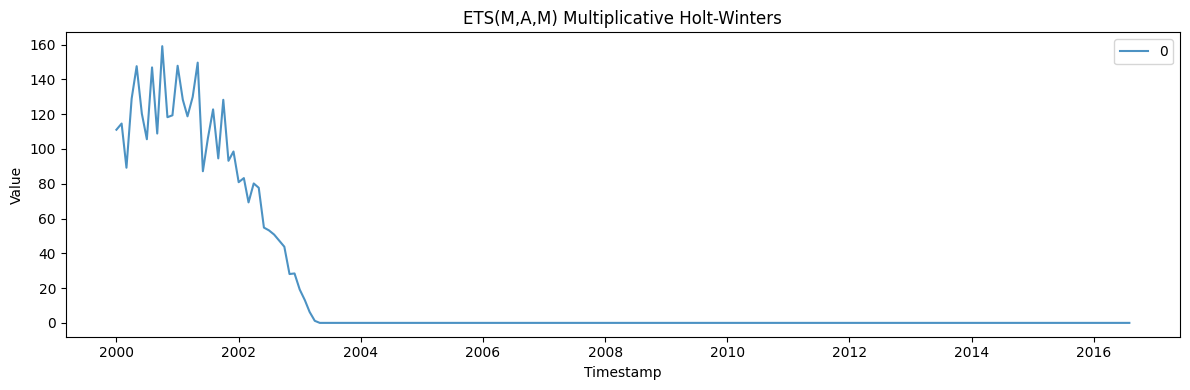

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_mul["unique_id"].unique().to_list():
    series = df_mul.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("ETS(M,A,M) Multiplicative Holt-Winters")
ax.legend()
plt.tight_layout()
plt.show()

## Example 4: Simple Exponential Smoothing ETS(A,N,N)

A model with no trend and no seasonality -- just level smoothing with additive errors.

In [ ]:
params_ses = {
    "min_length": 100,
    "max_length": 100,
    "freq": "D",
    "error_type": "add",
    "trend_type": None,
    "seasonal_type": None,
    "level": 50.0,
    "alpha": 0.2,
    "noise_std": 5.0,
    "seed": 789,
}

generator_ses = ETSGenerator(engine="polars", **params_ses)
df_ses = generator_ses.generate(n_series=1)

print(f"Model: {generator_ses.get_model_info()['model']}")
print(f"Mean: {df_ses['y'].mean():.2f}")
print(f"Std: {df_ses['y'].std():.2f}")
print(f"Min: {df_ses['y'].min():.2f}")
print(f"Max: {df_ses['y'].max():.2f}")

Model: ETS(A,N,N)
Mean: 55.54
Std: 6.25
Min: 39.97
Max: 69.52


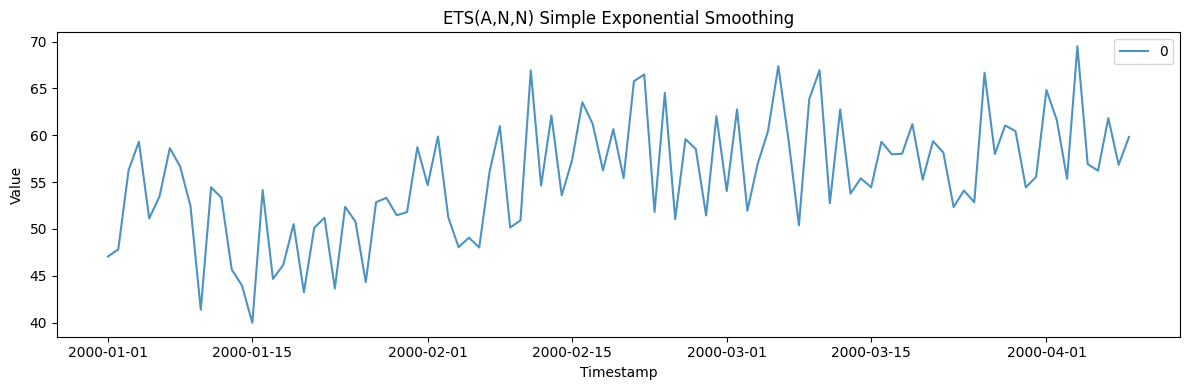

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_ses["unique_id"].unique().to_list():
    series = df_ses.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("ETS(A,N,N) Simple Exponential Smoothing")
ax.legend()
plt.tight_layout()
plt.show()

## Example 5: ETS with Box-Cox Transformation

Apply a Box-Cox transformation (lambda=0.5, square root) to the generated series.

In [ ]:
params_boxcox = {
    "min_length": 100,
    "max_length": 100,
    "freq": "D",
    "error_type": "add",
    "trend_type": "add",
    "seasonal_type": None,
    "level": 100.0,
    "trend": 0.5,
    "alpha": 0.3,
    "beta": 0.1,
    "noise_std": 0.5,
    "box_cox_lambda": 0.5,
    "seed": 111,
}

generator_boxcox = ETSGenerator(engine="polars", **params_boxcox)
df_boxcox = generator_boxcox.generate(n_series=1)

print(f"Model: {generator_boxcox.get_model_info()['model']}")
print(f"Box-Cox lambda: {generator_boxcox.get_model_info()['box_cox_lambda']}")
print(f"Mean: {df_boxcox['y'].mean():.2f}")
print(f"Std: {df_boxcox['y'].std():.2f}")

Model: ETS(A,A,N)
Box-Cox lambda: 0.5
Mean: 115.15
Std: 5.02


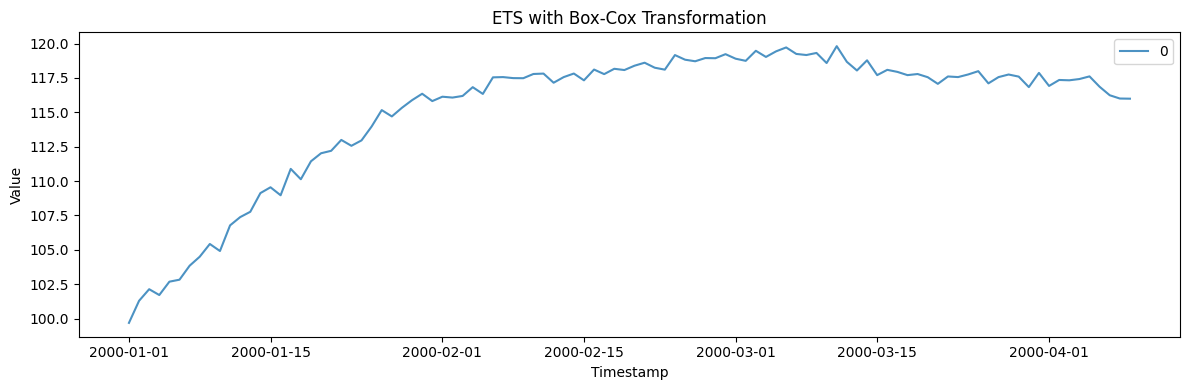

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in df_boxcox["unique_id"].unique().to_list():
    series = df_boxcox.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("ETS with Box-Cox Transformation")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [SARIMA](sarima) — the ARIMA view of the same trend/seasonal structure.
- [Seasonal](seasonal) — a fixed seasonal wave when you don't need evolving states.

The full error/trend/season taxonomy is in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::